In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
import pickle
from sklearn.model_selection import cross_val_predict, LeaveOneOut
from sklearn.metrics import r2_score, root_mean_squared_error, 

In [2]:
anionic = pd.read_csv('Data_anionic.csv', index_col = 0)
non_ionic = pd.read_csv('Data_non_ionic.csv', index_col = 0)
extended = pd.read_csv('Data_extended.csv', index_col = 0)

**Anionic**

In [3]:
with_boundaries_anionic = anionic[~anionic['Upper'].isna() & ~anionic['Lower'].isna()]
indices_with_boundaries = with_boundaries_anionic.index.to_numpy()

In [4]:
boundaries = with_boundaries_anionic.loc[:, ['Upper', 'Lower']].to_numpy().transpose()
boundaries = (boundaries[0,:] - boundaries[1,:])/2

In [5]:
pipe = make_pipeline(StandardScaler(), Ridge(solver = 'auto', alpha = 3.6571746488380943))

In [6]:
with open('../Only anionics/padel_descks.pickle', 'rb') as inp:
    descs_anionic = pickle.load(inp)['Padel_anionic']

In [7]:
target = pd.read_csv('../Only anionics/Data_anionic.csv')['Cc ']

In [9]:
loo = LeaveOneOut()

In [10]:
y_pred = cross_val_predict(pipe, X = descs_anionic, y = target, cv = loo)

<ErrorbarContainer object of 3 artists>

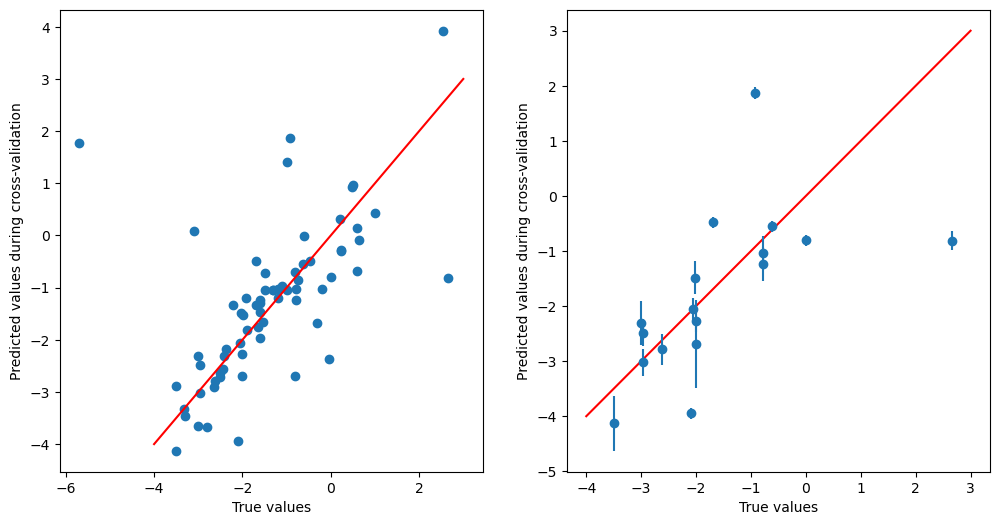

In [11]:
fig, axes = plt.subplots(1,2, figsize = (12,6))

axes[0].scatter(target, y_pred)
axes[0].plot([-4,3], [-4,3], c = 'r')
axes[0].set_xlabel('True values')
axes[0].set_ylabel('Predicted values during cross-validation')

axes[1].set_xlabel('True values')
axes[1].set_ylabel('Predicted values during cross-validation')
axes[1].plot([-4,3], [-4,3], c = 'r')
axes[1].errorbar(target[indices_with_boundaries], y_pred[indices_with_boundaries], fmt = 'o', yerr = boundaries)

In [13]:
r2_score(target, y_pred)

0.11886959888697934

In [15]:
root_mean_squared_error(target, y_pred)

1.3387684632035304